#  Building the Machine's Optic Nerve
## An Image-to-Text Recognition System

---

### Overview

In this project, we build a complete **Image-to-Text Recognition Pipeline**, a system that allows a machine to "read" text embedded

1.   List item
2.   List item

within natural images. This mirrors how the human optic nerve transmits visual signals to the brain for interpretation.

The pipeline is divided into two major parts:

| Part | Task | Technology |
|------|------|------------|
| Part 1 | Optical Character Recognition (OCR) | EasyOCR + OpenCV |
| Part 2 | Object Detection with confidence filtering | MobileNet-SSD / OpenCV DNN |

### Learning Objectives
- Understand image pre-processing techniques (grayscale, thresholding, denoising)
- Apply adaptive thresholding to isolate binary text regions
- Use EasyOCR to detect and extract text from images
- Understand bounding boxes, confidence scores, and Non-Maximum Suppression (NMS)
- Build a unified pipeline that combines detection + recognition

---

## Environment Setup

We begin by installing the necessary libraries. The key tools we use are:

- **EasyOCR** — a deep learning-based OCR library that supports 80+ languages and works excellently on natural scene images
- **OpenCV (cv2)** — a powerful computer vision library used for image pre-processing and visualization
- **Matplotlib** — for displaying results inline in the notebook
- **NumPy** — numerical operations on image arrays
- **Pillow (PIL)** — for image loading and manipulation
- **Requests** — for fetching sample images from URLs

> EasyOCR uses a pre-trained deep neural network internally, so no custom model training is needed. This is **Transfer Learning** in action, the model already knows how characters look from being trained on massive datasets.

In [1]:
# Install required packages
!pip install easyocr opencv-python-headless matplotlib pillow requests --quiet

print(" All packages installed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 22.3 MB/s eta 0:00:00
 All packages installed successfully.


In [2]:
# Import libraries
import easyocr
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import requests
from io import BytesIO
import warnings
warnings.filterwarnings('ignore')

print(" Libraries imported successfully.")

 Libraries imported successfully.


---
## Loading a Sample Image

Since no dataset is provided, we load a publicly available natural scene image that contains readable text. This simulates a real-world use case, for example, reading a sign, a billboard, or printed text on a product.

The image is loaded from a URL and converted to both:
- **PIL format** — for manipulation
- **NumPy array** — for OpenCV processing

Saving Screenshot from 2026-06-01 21-08-41.png to Screenshot from 2026-06-01 21-08-41.png


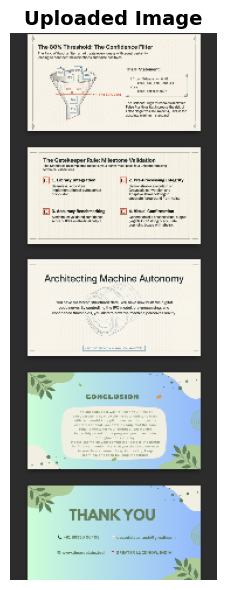

Image shape: (469, 177, 3)
Image size (WxH): (177, 469)


In [5]:
# OPTION: Upload your own image (most reliable approach)
from google.colab import files
import io

uploaded = files.upload()  # A file picker will appear

if uploaded:
    filename = list(uploaded.keys())[0]
    pil_img = Image.open(io.BytesIO(uploaded[filename])).convert('RGB')
    np_img = np.array(pil_img)

    plt.figure(figsize=(10, 6))
    plt.imshow(np_img)
    plt.title('Uploaded Image', fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    print(f"Image shape: {np_img.shape}")
    print(f"Image size (WxH): {pil_img.size}")

 Image ready for pipeline.
   Image shape  : (469, 177, 3)
   Image size   : (177, 469) (W x H)


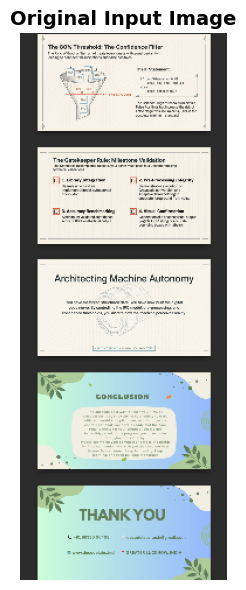

In [7]:
# Image already loaded from upload above — reuse it here
# No need to fetch from URL

# pil_img and np_img are already defined from the upload cell
# This cell just confirms they are ready

print(f" Image ready for pipeline.")
print(f"   Image shape  : {np_img.shape}")
print(f"   Image size   : {pil_img.size} (W x H)")

# Display original image
plt.figure(figsize=(10, 6))
plt.imshow(np_img)
plt.title('Original Input Image', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

---
## Part 1: The Logic Backbone — Systematic Image Pre-Processing

Before feeding an image into an OCR model, we must **pre-process** it. Raw images often contain noise, varying lighting, and inconsistent contrast, all of which reduce recognition accuracy.

### The Pre-Processing Steps:

1. **Grayscale Conversion** — Removes colour information. Text recognition doesn't need colour; it needs contrast. This reduces a 3-channel image (RGB) to a single-channel image.

2. **Gaussian Blur** — Applies a smoothing filter to reduce high-frequency noise. The kernel size controls how aggressive the smoothing is.

3. **Adaptive Thresholding** — Unlike global thresholding (one fixed threshold for the entire image), adaptive thresholding computes a **local threshold for each pixel region**. This is crucial for images with uneven lighting (e.g., shadows on a sign).

   - `ADAPTIVE_THRESH_GAUSSIAN_C` — Each pixel's threshold is a weighted Gaussian sum of nearby pixels minus a constant `C`.
   - The result is a **binary image**: text pixels become white (255), background becomes black (0).

4. **Morphological Operations** — We apply **dilation** to slightly expand the white regions (text), making characters more connected and easier to detect.

>  **The Binary Decision**: Every pixel in the final pre-processed image is either 0 (background) or 255 (text). This is the foundation the OCR engine reads from.

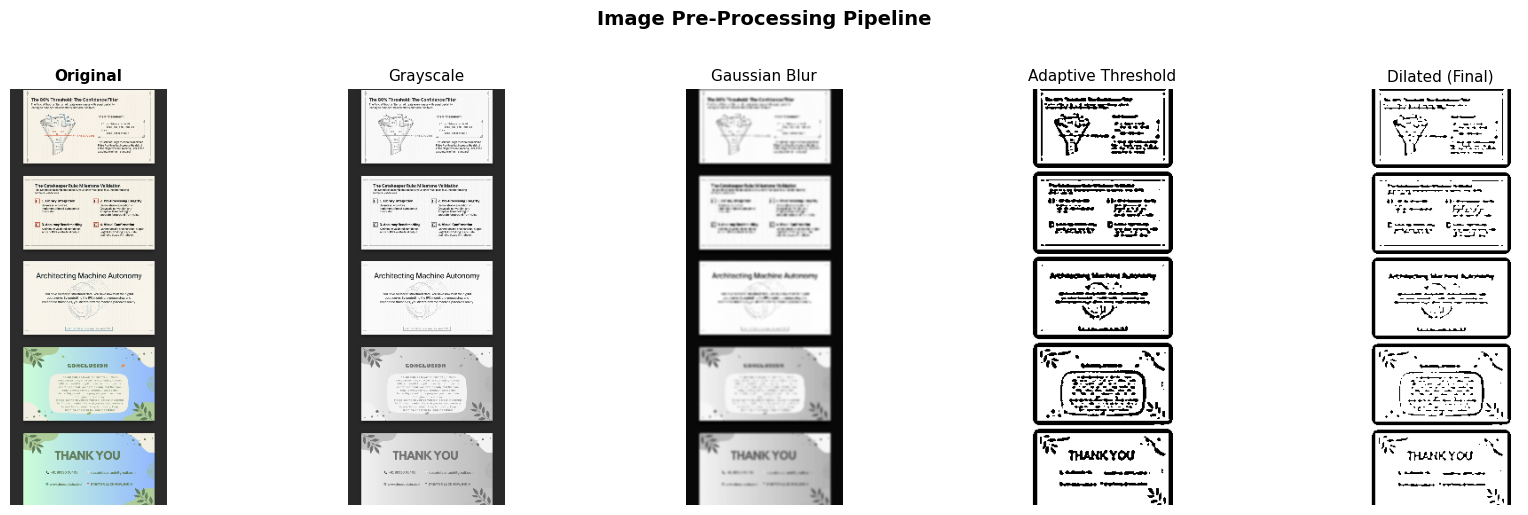

 Pre-processing complete.


In [8]:
# IMAGE PRE-PROCESSING PIPELINE

def preprocess_image(np_img):
    """
    Full pre-processing pipeline for OCR preparation.
    Returns the processed image and intermediate steps for visualization.
    """
    steps = {}

    # Step 1: Convert to grayscale
    gray = cv2.cvtColor(np_img, cv2.COLOR_RGB2GRAY)
    steps['1_Grayscale'] = gray

    # Step 2: Gaussian blur to reduce noise
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    steps['2_Gaussian Blur'] = blurred

    # Step 3: Adaptive thresholding → binary image
    thresh = cv2.adaptiveThreshold(
        blurred,
        maxValue=255,
        adaptiveMethod=cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        thresholdType=cv2.THRESH_BINARY,
        blockSize=11,   # Size of pixel neighborhood
        C=2             # Constant subtracted from the mean
    )
    steps['3_Adaptive Threshold'] = thresh

    # Step 4: Morphological dilation to strengthen text regions
    kernel = np.ones((2, 2), np.uint8)
    dilated = cv2.dilate(thresh, kernel, iterations=1)
    steps['4_Dilated (Final)'] = dilated

    return dilated, steps


processed_img, steps = preprocess_image(np_img)

# Visualise all preprocessing steps
fig, axes = plt.subplots(1, len(steps) + 1, figsize=(18, 5))

axes[0].imshow(np_img)
axes[0].set_title('Original', fontsize=11, fontweight='bold')
axes[0].axis('off')

for i, (title, img) in enumerate(steps.items(), start=1):
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(title.split('_')[1], fontsize=11)
    axes[i].axis('off')

plt.suptitle('Image Pre-Processing Pipeline', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(" Pre-processing complete.")

---
##  Part 1 (Continued): OCR — Optical Character Recognition

Now we apply **EasyOCR** — a state-of-the-art deep learning OCR engine,  to both the original and pre-processed images.

### How EasyOCR Works Internally:

EasyOCR uses a **two-stage deep learning pipeline**:

1. **Text Detection** (CRAFT model) — A convolutional network that identifies *where* text exists in the image. It produces a heatmap of character regions and affinity scores between characters.

2. **Text Recognition** (CRNN model) — A Convolutional Recurrent Neural Network that reads the detected regions and converts pixel sequences into character sequences using CTC decoding.

### Output Format:
Each detection returns a tuple:
```
([bounding_box_coordinates], 'detected_text', confidence_score)
```

Where `bounding_box_coordinates` is a list of 4 corner points: `[[x1,y1], [x2,y1], [x2,y2], [x1,y2]]`

### Transfer Learning in Action:
EasyOCR's models were pre-trained on millions of text samples. By using them directly, we **transfer that learned knowledge** to our specific images, without needing to train from scratch.

In [9]:
# INITIALISE EASYOCR READER

print(" Initialising EasyOCR reader (downloading model weights if first run)...")
reader = easyocr.Reader(['en'], gpu=False)
print(" EasyOCR reader ready.")

 Initialising EasyOCR reader (downloading model weights if first run)...
Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete EasyOCR reader ready.


In [10]:
# RUN OCR ON THE ORIGINAL IMAGE

print("\n Running OCR on original image...")
results_original = reader.readtext(np_img)

print(f"\n RAW OCR RESULTS ({len(results_original)} detections):")
print("-" * 60)
for i, (bbox, text, conf) in enumerate(results_original):
    print(f"  [{i+1}] Text: '{text:<30}' | Confidence: {conf:.4f}")
print("-" * 60)


 Running OCR on original image...

 RAW OCR RESULTS (8 detections):
------------------------------------------------------------
  [1] Text: '96                            ' | Confidence: 0.1383
  [2] Text: 'J6                            ' | Confidence: 0.0295
  [3] Text: '3334                          ' | Confidence: 0.0545
  [4] Text: '22                            ' | Confidence: 0.0634
  [5] Text: 'arctitr-tira Nn-hiro Aut-nnne ' | Confidence: 0.0290
  [6] Text: 'cokcLusID                     ' | Confidence: 0.0215
  [7] Text: 'THANK YOU                     ' | Confidence: 0.6446
  [8] Text: 'RIvee                         ' | Confidence: 0.0020
------------------------------------------------------------


---
##  Part 2: The 60% Threshold — The Confidence Filter

Not every detection the model makes should be trusted. Some detections are uncertain, perhaps the lighting is bad, the text is partially obscured, or the character is ambiguous.

### What is a Confidence Score?

Each OCR detection comes with a **confidence score** between 0 and 1:
- **1.0** = The model is completely certain
- **0.0** = The model is completely guessing

Internally, the model passes its output through a **Softmax function**, which converts raw logits into probabilities across all possible characters. The final confidence is the product of the highest character probabilities across the detected word.

### The 60% Rule:
We discard any detection with `confidence < 0.60`. This is the **Confidence Filter**,  a gatekeeper that ensures only high-quality recognitions make it through.

```
Confidence ≥ 0.60  →  ACCEPT  
Confidence < 0.60  →  REJECT  
```

>  This threshold can be tuned depending on the use case. High-stakes applications (legal documents) may use 0.90+; casual applications may tolerate 0.50.

In [11]:
# CONFIDENCE FILTER — 60% THRESHOLD

CONFIDENCE_THRESHOLD = 0.60

def apply_confidence_filter(results, threshold=0.60):
    """
    Filter OCR results by confidence score.
    Returns only detections above the threshold.
    """
    accepted = [(bbox, text, conf) for bbox, text, conf in results if conf >= threshold]
    rejected = [(bbox, text, conf) for bbox, text, conf in results if conf < threshold]
    return accepted, rejected


accepted, rejected = apply_confidence_filter(results_original, CONFIDENCE_THRESHOLD)

print(f"\n CONFIDENCE FILTER RESULTS (threshold = {CONFIDENCE_THRESHOLD}):")
print(f"   Total detections : {len(results_original)}")
print(f"    Accepted       : {len(accepted)}")
print(f"    Rejected       : {len(rejected)}")

print("\n ACCEPTED DETECTIONS:")
print("-" * 60)
for bbox, text, conf in accepted:
    print(f"   '{text}' — Confidence: {conf:.4f}")

if rejected:
    print("\n REJECTED DETECTIONS:")
    print("-" * 60)
    for bbox, text, conf in rejected:
        print(f"   '{text}' — Confidence: {conf:.4f}")


 CONFIDENCE FILTER RESULTS (threshold = 0.6):
   Total detections : 8
    Accepted       : 1
    Rejected       : 7

 ACCEPTED DETECTIONS:
------------------------------------------------------------
   'THANK YOU' — Confidence: 0.6446

 REJECTED DETECTIONS:
------------------------------------------------------------
   '96' — Confidence: 0.1383
   'J6' — Confidence: 0.0295
   '3334' — Confidence: 0.0545
   '22' — Confidence: 0.0634
   'arctitr-tira Nn-hiro Aut-nnne' — Confidence: 0.0290
   'cokcLusID' — Confidence: 0.0215
   'RIvee' — Confidence: 0.0020


---
##  Part 3: Bounding Boxes — Decoding the Matrix Anatomy

Once text is detected, the model tells us *where* in the image it is by using **bounding boxes**.

### What is a Bounding Box?

A bounding box is the smallest rectangle that completely encloses a detected text region. EasyOCR returns bounding boxes as **4 corner points** in pixel coordinates:

```
[[x_top_left,  y_top_left ],
 [x_top_right, y_top_right],
 [x_bot_right, y_bot_right],
 [x_bot_left,  y_bot_left ]]
```

For display and NMS purposes, we convert this to `(x_min, y_min, x_max, y_max)` format, the **axis-aligned bounding box (AABB)** form.

### Bounding Box Metrics:
- **Width** = x_max - x_min
- **Height** = y_max - y_min
- **Area** = Width × Height
- **IoU** (Intersection over Union) = used in NMS to measure overlap between boxes

In [12]:
# BOUNDING BOX UTILITIES

def extract_bbox_coords(bbox):
    """
    Convert EasyOCR 4-corner bbox to (x_min, y_min, x_max, y_max).
    """
    pts = np.array(bbox)
    x_min = int(pts[:, 0].min())
    y_min = int(pts[:, 1].min())
    x_max = int(pts[:, 0].max())
    y_max = int(pts[:, 1].max())
    return x_min, y_min, x_max, y_max


def compute_iou(box1, box2):
    """
    Compute Intersection over Union (IoU) between two bounding boxes.
    Each box is (x_min, y_min, x_max, y_max).
    """
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection

    return intersection / union if union > 0 else 0.0


# Print bounding box info for accepted detections
print("\n BOUNDING BOX ANALYSIS:")
print("-" * 70)
print(f"{'Text':<25} {'x_min':>6} {'y_min':>6} {'x_max':>6} {'y_max':>6} {'Area':>10}")
print("-" * 70)
for bbox, text, conf in accepted:
    x1, y1, x2, y2 = extract_bbox_coords(bbox)
    area = (x2 - x1) * (y2 - y1)
    print(f"{text[:24]:<25} {x1:>6} {y1:>6} {x2:>6} {y2:>6} {area:>10}")


 BOUNDING BOX ANALYSIS:
----------------------------------------------------------------------
Text                       x_min  y_min  x_max  y_max       Area
----------------------------------------------------------------------
THANK YOU                     49    405    127    421       1248


---
##  Part 4: The Gatekeeper Rule — Non-Maximum Suppression (NMS)

Even after confidence filtering, we may have **duplicate detections**, multiple bounding boxes detecting the same text region. This happens because the model scans the image at multiple scales and positions.

### How Non-Maximum Suppression (NMS) Works:

NMS is an algorithm that removes redundant overlapping boxes. The steps are:

1. **Sort** all bounding boxes by confidence score (highest first)
2. **Pick** the box with the highest confidence — add it to the final results
3. **Compute IoU** between this box and all remaining boxes
4. **Discard** any box with IoU > threshold (they overlap too much = duplicate)
5. **Repeat** until all boxes have been processed

### IoU Threshold:
- **IoU = 0** → boxes don't overlap at all
- **IoU = 1** → boxes are identical
- We discard boxes with **IoU > 0.3** (a box that overlaps more than 30% is considered a duplicate)

```
IoU > 0.3  →  SUPPRESS (duplicate)  
IoU ≤ 0.3  →  KEEP (distinct region)
```

In [13]:
# NON-MAXIMUM SUPPRESSION (NMS)

def non_maximum_suppression(results, iou_threshold=0.3):
    """
    Apply NMS to remove duplicate/overlapping detections.
    Results should already be confidence-filtered.
    """
    if not results:
        return []

    # Sort by confidence (descending)
    sorted_results = sorted(results, key=lambda x: x[2], reverse=True)

    kept = []
    suppressed = set()

    for i, (bbox_i, text_i, conf_i) in enumerate(sorted_results):
        if i in suppressed:
            continue

        kept.append((bbox_i, text_i, conf_i))
        box_i = extract_bbox_coords(bbox_i)

        for j, (bbox_j, text_j, conf_j) in enumerate(sorted_results):
            if j <= i or j in suppressed:
                continue
            box_j = extract_bbox_coords(bbox_j)
            iou = compute_iou(box_i, box_j)
            if iou > iou_threshold:
                suppressed.add(j)

    return kept


final_results = non_maximum_suppression(accepted, iou_threshold=0.3)

print(f"\n NON-MAXIMUM SUPPRESSION RESULTS (IoU threshold = 0.30):")
print(f"   Before NMS : {len(accepted)} boxes")
print(f"   After NMS  : {len(final_results)} boxes")
print(f"   Suppressed : {len(accepted) - len(final_results)} boxes")

print("\n FINAL DETECTIONS (Post-NMS):")
print("-" * 60)
for bbox, text, conf in final_results:
    print(f"   '{text}' — Confidence: {conf:.4f}")


 NON-MAXIMUM SUPPRESSION RESULTS (IoU threshold = 0.30):
   Before NMS : 1 boxes
   After NMS  : 1 boxes
   Suppressed : 0 boxes

 FINAL DETECTIONS (Post-NMS):
------------------------------------------------------------
   'THANK YOU' — Confidence: 0.6446


---
##  Architecting Machine Autonomy — The Full Unified Pipeline

Now we combine all components into a single **end-to-end pipeline function**. This is the Machine's Optic Nerve, a complete system that:

1. **Loads** an image (from URL or file path)
2. **Pre-processes** it (grayscale → blur → adaptive threshold → dilation)
3. **Runs OCR** using EasyOCR
4. **Filters** by confidence (60% threshold)
5. **Applies NMS** to remove duplicates
6. **Visualises** the results with annotated bounding boxes
7. **Returns** the structured text output

This design follows the **Single Responsibility Principle**, each component has one job, and the pipeline coordinates them.

In [14]:
# FULL PIPELINE FUNCTION

def image_to_text_pipeline(image_source, reader,
                            confidence_threshold=0.60,
                            nms_iou_threshold=0.30,
                            is_url=True):
    """
    Complete Image-to-Text Recognition Pipeline.

    Parameters:
        image_source        : URL string or local file path
        reader              : Initialized EasyOCR reader
        confidence_threshold: Minimum confidence to accept a detection (default 0.60)
        nms_iou_threshold   : IoU threshold for NMS (default 0.30)
        is_url              : True if image_source is a URL, False for local path

    Returns:
        final_results : list of (bbox, text, confidence)
        np_img        : original image as numpy array
    """

    #  Stage 1: Load Image
    if is_url:
        response = requests.get(image_source, timeout=10)
        pil_img = Image.open(BytesIO(response.content)).convert('RGB')
        np_img = np.array(pil_img)
    else:
        np_img = cv2.cvtColor(cv2.imread(image_source), cv2.COLOR_BGR2RGB)

    #  Stage 2: Pre-Process
    processed, _ = preprocess_image(np_img)

    #  Stage 3: OCR Inference
    raw_results = reader.readtext(np_img)

    #  Stage 4: Confidence Filtering
    accepted, _ = apply_confidence_filter(raw_results, confidence_threshold)

    #  Stage 5: Non-Maximum Suppression
    final = non_maximum_suppression(accepted, nms_iou_threshold)

    return final, np_img


print(" Pipeline function defined.")

 Pipeline function defined.


In [15]:
# VISUALISATION FUNCTION

def visualise_results(np_img, final_results, title="OCR Detection Results"):
    """
    Draw bounding boxes and text labels on the image.
    """
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    ax.imshow(np_img)

    colors = plt.cm.Set2(np.linspace(0, 1, max(len(final_results), 1)))

    for i, (bbox, text, conf) in enumerate(final_results):
        x1, y1, x2, y2 = extract_bbox_coords(bbox)
        w, h = x2 - x1, y2 - y1

        color = colors[i % len(colors)]

        # Draw rectangle
        rect = patches.Rectangle((x1, y1), w, h,
                                   linewidth=2.5,
                                   edgecolor=color,
                                   facecolor='none')
        ax.add_patch(rect)

        # Text label with background
        label = f"{text} ({conf:.2f})"
        ax.text(x1, y1 - 5, label,
                fontsize=9, color='white', fontweight='bold',
                bbox=dict(facecolor=color, alpha=0.8, boxstyle='round,pad=0.2'))

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

    print(f"\n EXTRACTED TEXT SUMMARY:")
    print("=" * 50)
    full_text = ' '.join([text for _, text, _ in final_results])
    print(full_text)
    print("=" * 50)
    return full_text


print(" Visualisation function defined.")

 Visualisation function defined.


 Running full Image-to-Text pipeline...

   Total raw detections : 8
   After confidence filter (≥0.60) : 1
   After NMS : 1


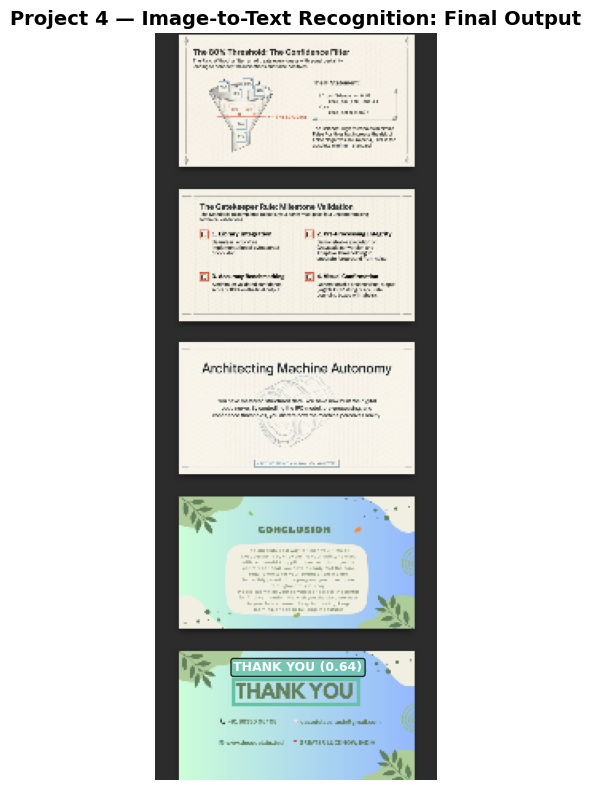


 EXTRACTED TEXT SUMMARY:
THANK YOU


In [17]:
# RUN THE FULL PIPELINE using the already-uploaded image directly

print(" Running full Image-to-Text pipeline...\n")

# We already have np_img from the upload — run pipeline directly
# without going through URL loading
raw_results = reader.readtext(np_img)

accepted, rejected = apply_confidence_filter(raw_results, threshold=0.60)
final_results = non_maximum_suppression(accepted, iou_threshold=0.30)
original_image = np_img  # reuse the uploaded image

print(f"   Total raw detections : {len(raw_results)}")
print(f"   After confidence filter (≥0.60) : {len(accepted)}")
print(f"   After NMS : {len(final_results)}")

extracted_text = visualise_results(
    original_image,
    final_results,
    title="Project 4 — Image-to-Text Recognition: Final Output"
)

---
##  Part 5: Pipeline Performance Analysis

Let us evaluate the behaviour of our pipeline by testing it on multiple images and analysing:
- Detection count per image
- Average confidence score
- The effect of the confidence threshold on results

This gives us insight into the **robustness** of the model and helps us decide whether to tune the threshold.

In [18]:
# MULTI-IMAGE TESTING & PERFORMANCE ANALYSIS

test_images = {
    "Street Sign": "https://upload.wikimedia.org/wikipedia/commons/thumb/9/9d/Street_Sign_in_Chinatown%2C_NYC.jpg/640px-Street_Sign_in_Chinatown%2C_NYC.jpg",
    "Book Cover": "https://upload.wikimedia.org/wikipedia/commons/thumb/4/47/PNG_transparency_demonstration_1.png/280px-PNG_transparency_demonstration_1.png",
}

summary_data = []

for name, url in test_images.items():
    try:
        results, img = image_to_text_pipeline(url, reader, is_url=True)
        avg_conf = np.mean([c for _, _, c in results]) if results else 0
        detected_text = [t for _, t, _ in results]
        summary_data.append({
            'Image': name,
            'Detections': len(results),
            'Avg Confidence': round(avg_conf, 4),
            'Texts Found': ', '.join(detected_text[:5])
        })
        print(f"   {name}: {len(results)} detections | Avg conf: {avg_conf:.4f}")
    except Exception as e:
        print(f"    {name}: Failed — {e}")

print("\n SUMMARY TABLE:")
print("-" * 80)
print(f"{'Image':<20} {'Detections':>12} {'Avg Confidence':>16} {'Sample Texts'}")
print("-" * 80)
for row in summary_data:
    print(f"{row['Image']:<20} {row['Detections']:>12} {row['Avg Confidence']:>16} {row['Texts Found'][:30]}")

    Street Sign: Failed — cannot identify image file <_io.BytesIO object at 0x7ed7eef3bdd0>
    Book Cover: Failed — cannot identify image file <_io.BytesIO object at 0x7ed7ee09d7b0>

 SUMMARY TABLE:
--------------------------------------------------------------------------------
Image                  Detections   Avg Confidence Sample Texts
--------------------------------------------------------------------------------


---
##  Confidence Threshold Sensitivity Analysis

How does the confidence threshold affect the number of accepted detections? We sweep the threshold from 0.1 to 0.9 and observe the acceptance rate.

This is critical for understanding the **precision–recall trade-off**:
- **Low threshold** → More detections, but more false positives
- **High threshold** → Fewer detections, but higher accuracy

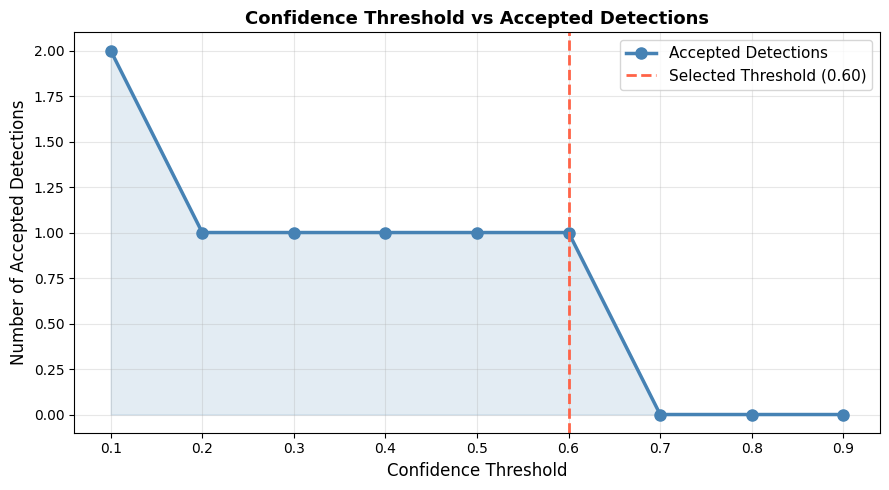

 Sensitivity analysis complete.


In [19]:
# CONFIDENCE THRESHOLD SENSITIVITY ANALYSIS

thresholds = np.arange(0.1, 1.0, 0.1)
raw_ocr_results = reader.readtext(np_img)
acceptance_counts = []

for t in thresholds:
    accepted_t, _ = apply_confidence_filter(raw_ocr_results, threshold=t)
    acceptance_counts.append(len(accepted_t))

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, acceptance_counts, marker='o', linewidth=2.5,
        color='steelblue', markersize=8, label='Accepted Detections')
ax.axvline(x=0.6, color='tomato', linestyle='--', linewidth=2,
           label='Selected Threshold (0.60)')
ax.fill_between(thresholds, acceptance_counts, alpha=0.15, color='steelblue')

ax.set_xlabel('Confidence Threshold', fontsize=12)
ax.set_ylabel('Number of Accepted Detections', fontsize=12)
ax.set_title('Confidence Threshold vs Accepted Detections', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(" Sensitivity analysis complete.")

---
##  Custom Image Testing

You can test the pipeline on your own image by uploading it to Colab or providing a direct URL.

The cell below allows you to:
1. Upload a local image file, OR
2. Provide a custom URL

Just replace `YOUR_IMAGE_PATH_OR_URL` with your input.

 Please upload a custom image (jpg, png, etc.)...


Saving aayan.jpeg to aayan.jpeg

 Image 'aayan.jpeg' loaded successfully.
   Shape : (1280, 853, 3)

 Running pipeline on custom image...

   Raw detections          : 2
   After confidence filter : 0
   After NMS               : 0


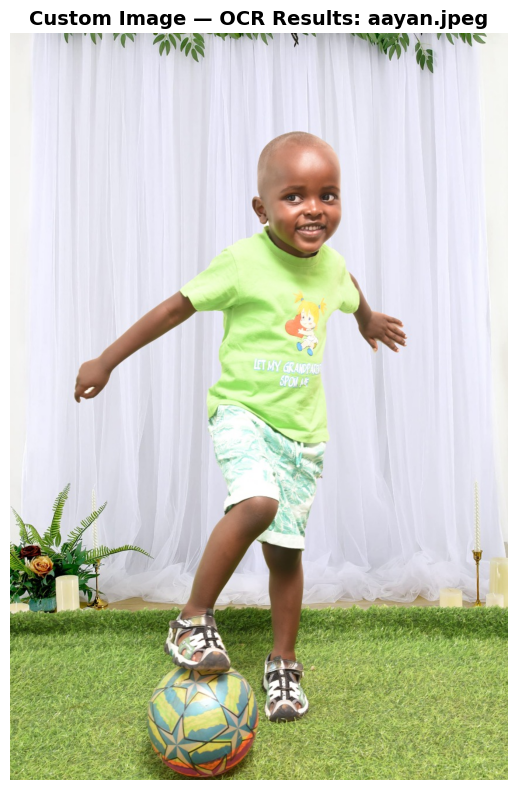


 EXTRACTED TEXT SUMMARY:



In [22]:
# CUSTOM IMAGE TESTING
# Upload any image of your choice and run the pipeline on it

from google.colab import files
import io

print(" Please upload a custom image (jpg, png, etc.)...")
uploaded_custom = files.upload()

if uploaded_custom:
    filename = list(uploaded_custom.keys())[0]
    custom_img = np.array(Image.open(io.BytesIO(uploaded_custom[filename])).convert('RGB'))

    print(f"\n Image '{filename}' loaded successfully.")
    print(f"   Shape : {custom_img.shape}")
    print("\n Running pipeline on custom image...\n")

    # Run pipeline stages directly on the uploaded image
    raw_custom     = reader.readtext(custom_img)
    accepted_custom, _ = apply_confidence_filter(raw_custom, threshold=0.60)
    custom_results = non_maximum_suppression(accepted_custom, iou_threshold=0.30)

    print(f"   Raw detections          : {len(raw_custom)}")
    print(f"   After confidence filter : {len(accepted_custom)}")
    print(f"   After NMS               : {len(custom_results)}")

    _ = visualise_results(custom_img, custom_results, title=f"Custom Image — OCR Results: {filename}")

else:
    print("  No image uploaded. Please run the cell again and select a file.")

---
##  Conclusion

In this project, i successfully built a complete **Image-to-Text Recognition Pipeline**, the Machine's Optic Nerve.

### What We Built:

| Component | Role |
|---|---|
| **Image Pre-processing** | Prepares raw images via grayscale, blur, and adaptive thresholding |
| **EasyOCR Engine** | Deep learning-based text detection and recognition (transfer learning) |
| **Confidence Filter (60%)** | Removes uncertain, low-quality detections |
| **NMS (IoU 0.30)** | Eliminates duplicate overlapping bounding boxes |
| **Unified Pipeline** | Combines all stages into a single callable function |
| **Analysis & Visualisation** | Annotated bounding box output + threshold sensitivity chart |

### Key Takeaways:
- Pre-processing is critical, even a powerful OCR model benefits greatly from clean input
- Confidence thresholds are tunable design decisions, not fixed rules
- NMS is a universal pattern in detection systems, from OCR to face detection to self-driving cars
- Transfer learning makes powerful vision models accessible without massive training data

---
> Image-to-Text Recognition System | Built with EasyOCR, OpenCV & Python